# SELIC – Entendendo, Coletando e Analisando as Séries do Banco Central

Este notebook apresenta:

**1. O que é a SELIC**  
**2. Diferença entre SELIC Over e SELIC Meta**  
**3. Como cada série é usada na economia**  
**4. Como coletar os dados via pipeline**  
**5. Como armazenar no PostgreSQL**  
**6. Como consultar e analisar**  

Vamos começar entendendo os conceitos.

# 1. O que é a SELIC?

A SELIC é a taxa básica de juros da economia brasileira.
Ela influencia:
- crédito
- inflação
- câmbio
- investimentos
- decisões de política monetária

Mas existem **duas SELICs diferentes**, e isso gera muita confusão:

## ✔ SELIC Meta (SGS 432)
- É a **taxa definida pelo Copom** a cada 45 dias.
- É **anual**, por exemplo: 10,75% ao ano.
- É um **instrumento de política monetária**.
- É a taxa que aparece no noticiário.

## ✔ SELIC Over (SGS 11)
- É a **taxa efetiva diária** das operações compromissadas.
- É calculada pelo mercado, não pelo Copom.
- É a taxa **que realmente acontece no dia a dia**.
- É usada para:
  - Tesouro Selic
  - CDI (que acompanha a SELIC)
  - remuneração de caixa

A SELIC Over oscila diariamente, enquanto a SELIC Meta muda poucas vezes ao ano.

# 2. Diferença prática entre as duas

| Característica | SELIC Meta | SELIC Over |
|----------------|------------|------------|
| Quem define | Copom | Mercado |
| Frequência | A cada 45 dias | Diária |
| Unidade | % ao ano | % ao dia |
| Uso | Política monetária | Operações financeiras |
| Volatilidade | Baixa | Alta |

A SELIC Over costuma ficar **muito próxima** da SELIC Meta, mas não igual.

# 3. Ajustar o PYTHONPATH para importar `src/`

In [1]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)
print("PYTHONPATH atualizado:", ROOT)

PYTHONPATH atualizado: /home/moacir/projects/ml/analytics/inflation


# 4. Importações

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.pipelines.selic_over import run_selic_over
from src.pipelines.selic_meta import run_selic_meta
from src.database.connection import engine

# 5. Executar pipelines

Isso irá:
- baixar SELIC Over (SGS 11)
- baixar SELIC Meta (SGS 432)
- criar automaticamente as tabelas:
  - `bcb.selic_over`
  - `bcb.selic_meta`
- inserir os dados

In [ ]:
run_selic_over()
run_selic_meta()

# 6. Verificar tabelas existentes

In [3]:
pd.read_sql("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'bcb'
ORDER BY table_name;
""", engine)

,table_name
0,ipca
1,selic_meta
2,selic_over


# 7. Carregar dados do banco

In [4]:
selic_over = pd.read_sql("SELECT * FROM bcb.selic_over ORDER BY date;", engine)
selic_meta = pd.read_sql("SELECT * FROM bcb.selic_meta ORDER BY date;", engine)

selic_over.head(), selic_meta.head()

(        date     value  series_id
 0 2000-01-03  0.069186         11
 1 2000-01-04  0.069186         11
 2 2000-01-05  0.069220         11
 3 2000-01-06  0.069286         11
 4 2000-01-07  0.069286         11,
         date  value  series_id
 0 1999-03-05   45.0        432
 1 1999-03-06   45.0        432
 2 1999-03-07   45.0        432
 3 1999-03-08   45.0        432
 4 1999-03-09   45.0        432)

# 8. Últimos valores

In [5]:
print("Últimos valores da SELIC Over:")
display(pd.read_sql("SELECT * FROM bcb.selic_over ORDER BY date DESC LIMIT 10;", engine))

print("Últimos valores da SELIC Meta:")
display(pd.read_sql("SELECT * FROM bcb.selic_meta ORDER BY date DESC LIMIT 10;", engine))

Últimos valores da SELIC Over:


,date,value,series_id
0,2026-04-17,0.054266,11
1,2026-04-16,0.054266,11
2,2026-04-15,0.054266,11
3,2026-04-14,0.054266,11
4,2026-04-13,0.054266,11
5,2026-04-10,0.054266,11
6,2026-04-09,0.054266,11
7,2026-04-08,0.054266,11
8,2026-04-07,0.054266,11
9,2026-04-06,0.054266,11


Últimos valores da SELIC Meta:


,date,value,series_id
0,2026-04-29,14.75,432
1,2026-04-28,14.75,432
2,2026-04-27,14.75,432
3,2026-04-26,14.75,432
4,2026-04-25,14.75,432
5,2026-04-24,14.75,432
6,2026-04-23,14.75,432
7,2026-04-22,14.75,432
8,2026-04-21,14.75,432
9,2026-04-20,14.75,432


# 9. Gráfico da SELIC Over (diária)

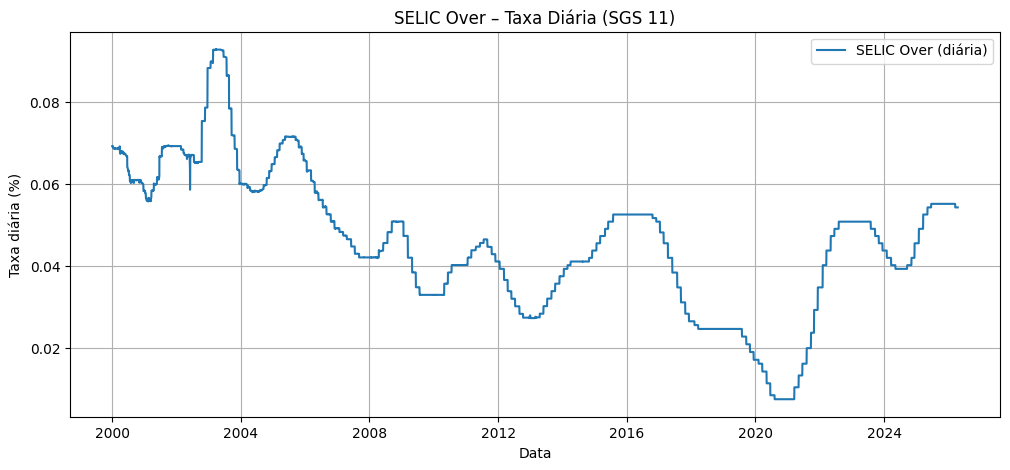

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(selic_over["date"], selic_over["value"], label="SELIC Over (diária)")
plt.title("SELIC Over – Taxa Diária (SGS 11)")
plt.xlabel("Data")
plt.ylabel("Taxa diária (%)")
plt.grid(True)
plt.legend()
plt.show()

# 10. Gráfico da SELIC Meta (anual)

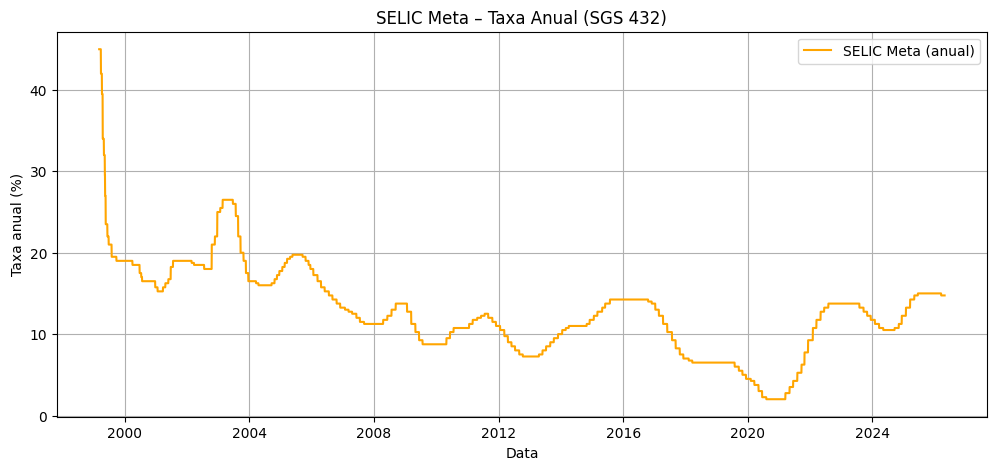

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(selic_meta["date"], selic_meta["value"], color="orange", label="SELIC Meta (anual)")
plt.title("SELIC Meta – Taxa Anual (SGS 432)")
plt.xlabel("Data")
plt.ylabel("Taxa anual (%)")
plt.grid(True)
plt.legend()
plt.show()

# 11. Comparação correta

Como as unidades são diferentes:
- SELIC Over = diária
- SELIC Meta = anual

Não faz sentido colocar no mesmo gráfico.

A comparação correta é **visual**, em dois gráficos sincronizados.

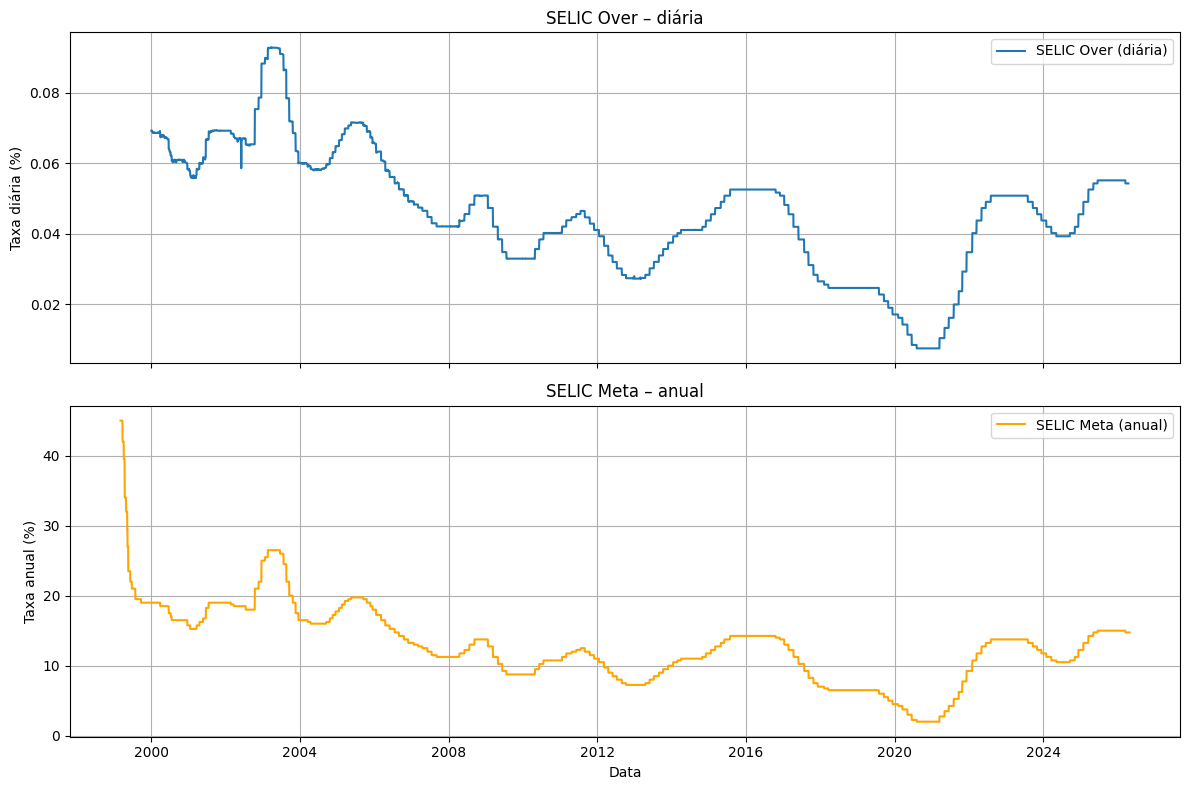

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(selic_over["date"], selic_over["value"], label="SELIC Over (diária)")
axes[0].set_title("SELIC Over – diária")
axes[0].set_ylabel("Taxa diária (%)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(selic_meta["date"], selic_meta["value"], color="orange", label="SELIC Meta (anual)")
axes[1].set_title("SELIC Meta – anual")
axes[1].set_xlabel("Data")
axes[1].set_ylabel("Taxa anual (%)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# 12. SELIC Over anualizada (opcional)

Para comparar níveis de juros, podemos anualizar a taxa diária:

$$ (1 + r_{dia})^{252} - 1 $$

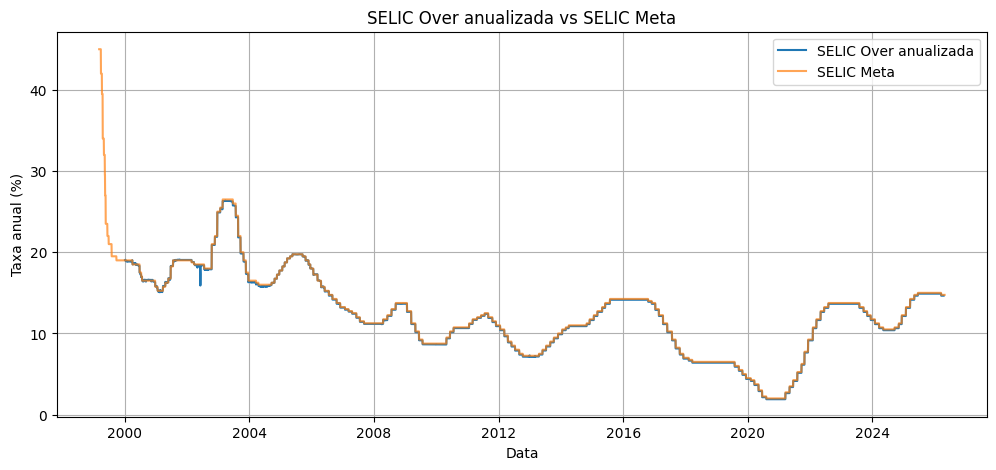

In [9]:
selic_over["value_aa"] = (1 + selic_over["value"] / 100) ** 252 - 1

plt.figure(figsize=(12, 5))
plt.plot(selic_over["date"], selic_over["value_aa"] * 100, label="SELIC Over anualizada")
plt.plot(selic_meta["date"], selic_meta["value"], label="SELIC Meta", alpha=0.7)
plt.title("SELIC Over anualizada vs SELIC Meta")
plt.xlabel("Data")
plt.ylabel("Taxa anual (%)")
plt.grid(True)
plt.legend()
plt.show()